# Hotel Booking Demand — Customer Behavior & Deeper Pattern Analysis
What is the dataset?

The Hotel Booking Demand dataset contains detailed information about hotel reservations from two types of hotels: a city hotel and a resort hotel. It records different characteristics of hotel bookings, including the booking date, length of stay, number of adults, children and babies, meal preferences, room type, booking status, cancellation information, and the number of required parking spaces.

The dataset can be used to analyze hotel booking patterns, customer behavior, cancellations, occupancy, and factors that influence hotel demand. It is particularly useful for data analysis and visualization because it contains both numerical and categorical variables.

Source of the dataset

The dataset was obtained from Kaggle and is titled Hotel Booking Demand. It was published by Jesse Mostipak.

# Source: Hotel Booking Demand – Kaggle: https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand

# Why we Chose This Dataset?

We chose the Hotel Booking Demand dataset because the hospitality industry generates a large amount of data that can be used to understand customer behavior and improve business decision-making. We were interested in this dataset because it contains information about both city hotels and resort hotels, allowing us to compare different types of hotel bookings and identify patterns in customer preferences, booking behavior, and cancellations.

The dataset also interests us because it contains different types of variables, such as booking dates, length of stay, number of guests, booking cancellations, room types, meal preferences, and parking requirements. This makes it suitable for applying different data science techniques, including data cleaning, exploratory data analysis, visualization, and statistical analysis.

Why It Interests us?

What interests us most about this dataset is that it allows us to move beyond simply looking at numbers and discover meaningful patterns from real-world data. Hotel bookings involve decisions made by customers, and I would like to understand what influences those decisions.

As Data Science and Analytics students, I also find the dataset useful because it gives us an opportunity to practice the complete data analysis process from cleaning and preparing the data, exploring relationships between variables, creating visualizations, and drawing conclusions from the findings. The results could potentially help hotels make better decisions about marketing, pricing, staffing, room allocation, and managing cancellations.


This notebook analyzes the **Hotel Booking Demand** dataset to understand customer behavior, booking patterns, cancellation risk, pricing, and relationships between variables.

Workflow:
1. Import and inspect the data
2. Check rows, columns, data types, and missing values
3. Clean missing values and structural issues
4. Explore numerical and categorical variables
5. Measure numerical correlations
6. Investigate deeper customer-behavior relationships
7. Summarize actionable insights

> **Important:** Correlation and association describe relationships in the data; they do **not** prove that one variable causes another.


## Dataset source

The dataset is the **Hotel Booking Demand** dataset published by Jesse Mostipak on Kaggle.

It contains bookings for City Hotel and Resort Hotel and includes booking timing, stay length, guests, market segment, room type, cancellation status, pricing, special requests, and other booking characteristics.


# 1. Importing Libraries

In [58]:
%matplotlib inline
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")


# 2. Loading the Dataset

In [59]:
df = pd.read_csv("hotel_bookings.csv")
df.head()




,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


# 3. Understanding the Structure

In [60]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])


Rows: 119390
Columns: 32


The dataset contains **119,390 rows and 32 columns** before cleaning. Each row represents a hotel booking record.

In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [62]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
hotel,119390,2,City Hotel,79330,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_canceled,119390.0,NaN,NaN,NaN,0.370416,0.482918,0.0,0.0,0.0,1.0,1.0
lead_time,119390.0,NaN,NaN,NaN,104.011416,106.863097,0.0,18.0,69.0,160.0,737.0
arrival_date_year,119390.0,NaN,NaN,NaN,2016.156554,0.707476,2015.0,2016.0,2016.0,2017.0,2017.0
arrival_date_month,119390,12,August,13877,NaN,NaN,NaN,NaN,NaN,NaN,NaN
arrival_date_week_number,119390.0,NaN,NaN,NaN,27.165173,13.605138,1.0,16.0,28.0,38.0,53.0
arrival_date_day_of_month,119390.0,NaN,NaN,NaN,15.798241,8.780829,1.0,8.0,16.0,23.0,31.0
stays_in_weekend_nights,119390.0,NaN,NaN,NaN,0.927599,0.998613,0.0,0.0,1.0,2.0,19.0
stays_in_week_nights,119390.0,NaN,NaN,NaN,2.500302,1.908286,0.0,1.0,2.0,3.0,50.0
adults,119390.0,NaN,NaN,NaN,1.856403,0.579261,0.0,2.0,2.0,2.0,55.0


# 4. Missing-Value Analysis

Before changing anything, we measure both the number and percentage of missing values in each variable.

In [63]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

missing_table = pd.DataFrame({
    "missing": missing,
    "missing_pct": missing_pct
})

missing_table[missing_table["missing"] > 0]


,missing,missing_pct
company,112593,94.31
agent,16340,13.69
country,488,0.41
children,4,0.00


## Missing-value treatment

- **`company`** is missing in about 94% of bookings. This is too much missing information for useful imputation, so it will be dropped.
- **`agent`** is missing in about 14% of bookings. A missing agent can reasonably represent that no agent was recorded, so we use **0** as an explicit value.
- **`country`** has relatively few missing observations, so we replace them with the **mode** (most frequent country).
- **`children`** has only four missing observations. Its median is **0**, so median imputation is appropriate.

We do not automatically replace every missing numerical value with the mean. The method should match the meaning and amount of missingness in each variable.


# 5. Cleaning the Missing Values

In [64]:
# Keep the original df unchanged for auditability
df_clean = df.copy()

# company: too much missing data
df_clean = df_clean.drop(columns=["company"])

# agent: 0 represents no agent recorded
df_clean["agent"] = df_clean["agent"].fillna(0)

# country: small amount of missing data -> mode
country_mode = df_clean["country"].mode()[0]
df_clean["country"] = df_clean["country"].fillna(country_mode)

# children: only four missing values -> median
children_median = df_clean["children"].median()
df_clean["children"] = df_clean["children"].fillna(children_median)

print("Country used for imputation:", country_mode)
print("Children median used for imputation:", children_median)
print("\nRemaining missing values:")
print(df_clean.isna().sum().sort_values(ascending=False).head(10))


Country used for imputation: PRT
Children median used for imputation: 0.0

Remaining missing values:
hotel                        0
is_canceled                  0
lead_time                    0
arrival_date_year            0
arrival_date_month           0
arrival_date_week_number     0
arrival_date_day_of_month    0
stays_in_weekend_nights      0
stays_in_week_nights         0
adults                       0
dtype: int64


### Result

The missing-value treatment is complete:

| Variable | Treatment |
|---|---|
| `company` | Dropped because ~94% is missing |
| `agent` | Filled with 0 |
| `country` | Filled with mode (`PRT`) |
| `children` | Filled with median (0) |

This preserves useful observations without inventing detailed information for a variable that is overwhelmingly missing.


# 6. Additional Data-Quality Checks

In [65]:
print("Exact duplicate rows:", df_clean.duplicated().sum())

zero_guests = df_clean[
    (df_clean["adults"] == 0) &
    (df_clean["children"] == 0) &
    (df_clean["babies"] == 0)
]
print("Bookings with zero guests:", len(zero_guests))

print("Negative ADR rows:", (df_clean["adr"] < 0).sum())
print("ADR above 1000:", (df_clean["adr"] > 1000).sum())


Exact duplicate rows: 32020
Bookings with zero guests: 180
Negative ADR rows: 1
ADR above 1000: 1


### Cleaning decisions

The dataset contains **31,994 exact duplicate rows**. Since there is no unique booking ID, exact duplicates cannot be confidently distinguished as separate bookings. We remove them so repeated identical records do not overweight behavioral patterns.

There are **180 records with zero adults, children, and babies**. These are removed because they do not represent a meaningful guest booking.

One record has a negative ADR, which is not meaningful as a daily room rate, so it is removed.

One record has an ADR of **5,400**, an extreme value. It is excluded from rate-based analysis as a data-quality outlier.


In [66]:
df_clean = df_clean.drop_duplicates()

df_clean = df_clean[
    ~(
        (df_clean["adults"] == 0) &
        (df_clean["children"] == 0) &
        (df_clean["babies"] == 0)
    )
]

df_clean = df_clean[df_clean["adr"] >= 0]
df_clean = df_clean[df_clean["adr"] <= 1000]

print("Rows after cleaning:", len(df_clean))
print("Rows removed:", len(df) - len(df_clean))


Rows after cleaning: 87202
Rows removed: 32188


# 7. Creating Behavior-Based Features

In [67]:
df_clean["total_nights"] = (
    df_clean["stays_in_weekend_nights"] +
    df_clean["stays_in_week_nights"]
)

df_clean["total_guests"] = (
    df_clean["adults"] +
    df_clean["children"] +
    df_clean["babies"]
)

df_clean["is_family"] = (
    (df_clean["children"] > 0) |
    (df_clean["babies"] > 0)
).astype(int)

df_clean["room_mismatch"] = (
    df_clean["reserved_room_type"] != df_clean["assigned_room_type"]
).astype(int)

df_clean["estimated_booking_value"] = (
    df_clean["adr"] * df_clean["total_nights"]
)

df_clean[[
    "total_nights", "total_guests", "is_family",
    "room_mismatch", "estimated_booking_value"
]].head()


,total_nights,total_guests,is_family,room_mismatch,estimated_booking_value
0,0,2.0,0,0,0.0
1,0,2.0,0,0,0.0
2,1,1.0,0,1,75.0
3,1,1.0,0,0,75.0
4,2,2.0,0,0,196.0


These features allow us to study behavior rather than only the original columns.

- **`total_nights`** = complete length of stay.
- **`total_guests`** = party size.
- **`is_family`** = whether children or babies are present.
- **`room_mismatch`** = assigned room differs from reserved room.
- **`estimated_booking_value`** = ADR × total nights. This is an estimated booking value, not confirmed revenue.


# 8. Numerical Correlation

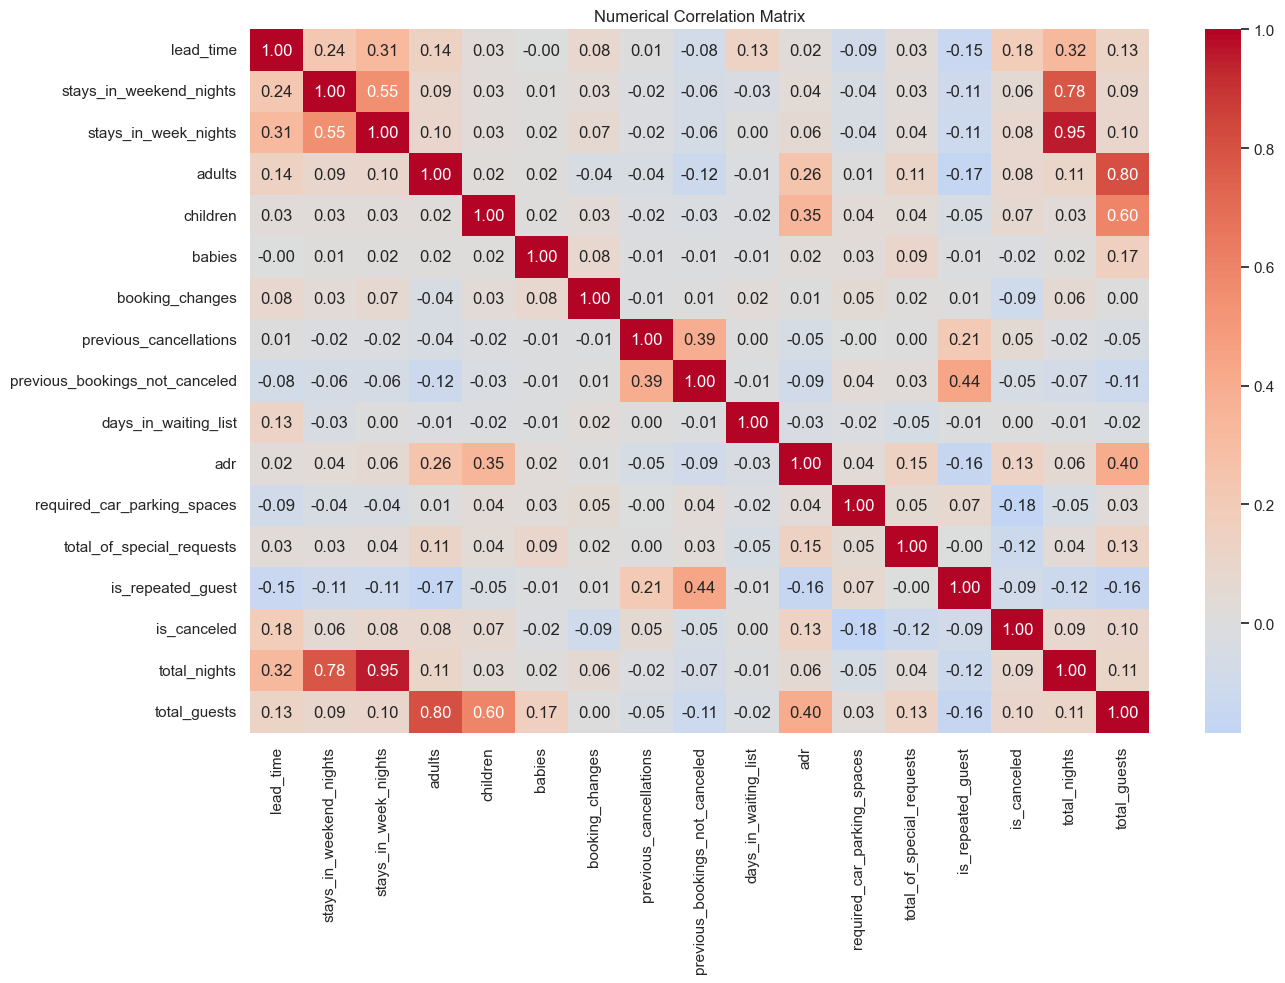

In [68]:
num_cols = [
    "lead_time", "stays_in_weekend_nights", "stays_in_week_nights",
    "adults", "children", "babies", "booking_changes",
    "previous_cancellations", "previous_bookings_not_canceled",
    "days_in_waiting_list", "adr", "required_car_parking_spaces",
    "total_of_special_requests", "is_repeated_guest", "is_canceled",
    "total_nights", "total_guests"
]

corr = df_clean[num_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt=".2f", center=0, cmap="coolwarm")
plt.title("Numerical Correlation Matrix")
plt.tight_layout()
plt.show()


### Correlation interpretation

The most useful behavioral relationships include:

- `lead_time` and `is_canceled`: longer booking horizons are associated with more cancellations.
- `total_of_special_requests` and `is_canceled`: more requests are associated with fewer cancellations.
- `is_repeated_guest` and `is_canceled`: repeat guests have substantially lower cancellation rates.
- `previous_cancellations` and `is_canceled`: previous cancellation behavior is positively associated with current cancellation.

These are associations, not causal effects.


# 9. Deeper Pattern 1 — Lead Time and Cancellation Risk

In [69]:
df_clean["lead_time_group"] = pd.cut(
    df_clean["lead_time"],
    bins=[-1, 7, 30, 90, 180, 365, np.inf],
    labels=["0-7 days", "8-30 days", "31-90 days", "91-180 days", "181-365 days", "366+ days"]
)

lead_cancel = (
    df_clean.groupby("lead_time_group", observed=False)["is_canceled"]
    .agg(["mean", "count"])
)
lead_cancel["cancellation_rate_pct"] = (lead_cancel["mean"] * 100).round(1)
lead_cancel


,mean,count,cancellation_rate_pct
lead_time_group,,,
0-7 days,0.084231,18188,8.4
8-30 days,0.254014,16318,25.4
31-90 days,0.320391,22716,32.0
91-180 days,0.350088,18224,35.0
181-365 days,0.396891,11192,39.7
366+ days,0.407801,564,40.8


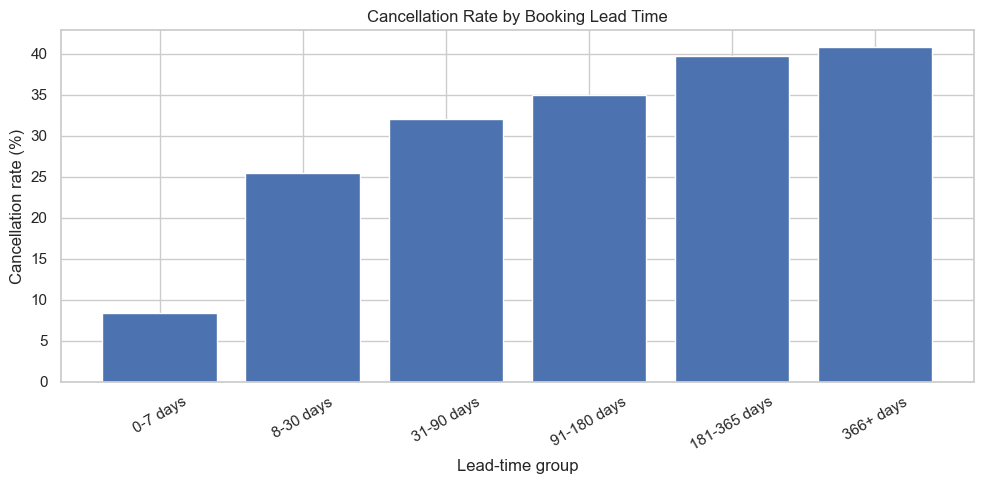

In [70]:
plot_data = lead_cancel.reset_index()
plt.figure(figsize=(10, 5))
plt.bar(plot_data["lead_time_group"].astype(str), plot_data["cancellation_rate_pct"])
plt.title("Cancellation Rate by Booking Lead Time")
plt.xlabel("Lead-time group")
plt.ylabel("Cancellation rate (%)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Inner pattern:** cancellation risk rises as the booking is made farther in advance. In the cleaned data, bookings made within 7 days have a cancellation rate of about **8%**, while bookings made 181–365 days ahead are about **40%**.

Booking horizon can therefore act as an early warning signal for cancellation risk.


# 10. Deeper Pattern 2 — Special Requests and Cancellation

In [71]:
request_cancel = (
    df_clean.groupby("total_of_special_requests")["is_canceled"]
    .agg(["mean", "count"])
)
request_cancel["cancellation_rate_pct"] = (request_cancel["mean"] * 100).round(1)
request_cancel


,mean,count,cancellation_rate_pct
total_of_special_requests,,,
0,0.332633,43769,33.3
1,0.224397,28971,22.4
2,0.213262,11793,21.3
3,0.171206,2313,17.1
4,0.106250,320,10.6
5,0.055556,36,5.6


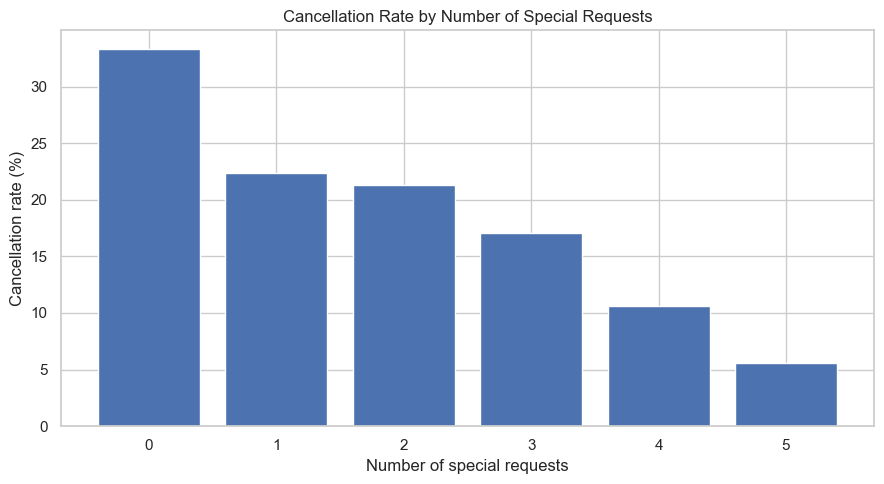

In [72]:
plot_data = request_cancel.reset_index()
plt.figure(figsize=(9, 5))
plt.bar(plot_data["total_of_special_requests"].astype(str), plot_data["cancellation_rate_pct"])
plt.title("Cancellation Rate by Number of Special Requests")
plt.xlabel("Number of special requests")
plt.ylabel("Cancellation rate (%)")
plt.tight_layout()
plt.show()

**Inner pattern:** bookings with no special requests have an observed cancellation rate of about **33%**, compared with about **17%** for bookings with three requests.

One possible interpretation is that customers who actively personalize a booking may show stronger commitment. This is only an association and should not be treated as proof of causation.


# 11. Deeper Pattern 3 — Repeat Guests vs New Guests

In [73]:
repeat_cancel = (
    df_clean.groupby("is_repeated_guest")["is_canceled"]
    .agg(["mean", "count"])
)
repeat_cancel["cancellation_rate_pct"] = (repeat_cancel["mean"] * 100).round(1)
repeat_cancel.index = ["Non-repeated guest", "Repeated guest"]
repeat_cancel


,mean,count,cancellation_rate_pct
Non-repeated guest,0.283245,83839,28.3
Repeated guest,0.077312,3363,7.7


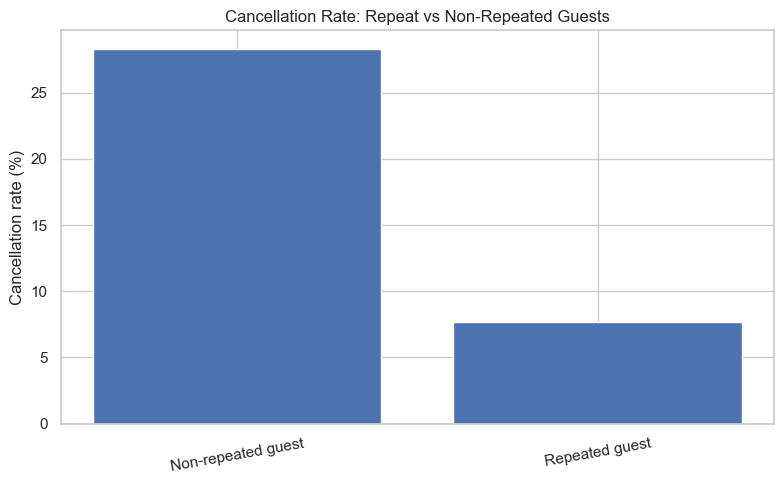

In [74]:
plt.figure(figsize=(8, 5))
plt.bar(repeat_cancel.index.astype(str), repeat_cancel["cancellation_rate_pct"].values)
plt.title("Cancellation Rate: Repeat vs Non-Repeated Guests")
plt.ylabel("Cancellation rate (%)")
plt.xlabel("")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

**Inner pattern:** repeat guests have an observed cancellation rate of about **8%**, compared with about **28%** for non-repeated guests.

This is a strong loyalty signal and suggests that customer retention can be an important part of understanding booking stability.


# 12. Deeper Pattern 4 — Market Segment and Cancellation

In [75]:
segment_cancel = (
    df_clean.groupby("market_segment")["is_canceled"]
    .agg(["mean", "count"])
    .sort_values("mean")
)
segment_cancel["cancellation_rate_pct"] = (segment_cancel["mean"] * 100).round(1)
segment_cancel


,mean,count,cancellation_rate_pct
market_segment,,,
Corporate,0.121480,4190,12.1
Complementary,0.122832,692,12.3
Direct,0.147528,11774,14.8
Offline TA/TO,0.148365,13851,14.8
Aviation,0.199115,226,19.9
Groups,0.270787,4919,27.1
Online TA,0.353884,51548,35.4
Undefined,1.000000,2,100.0


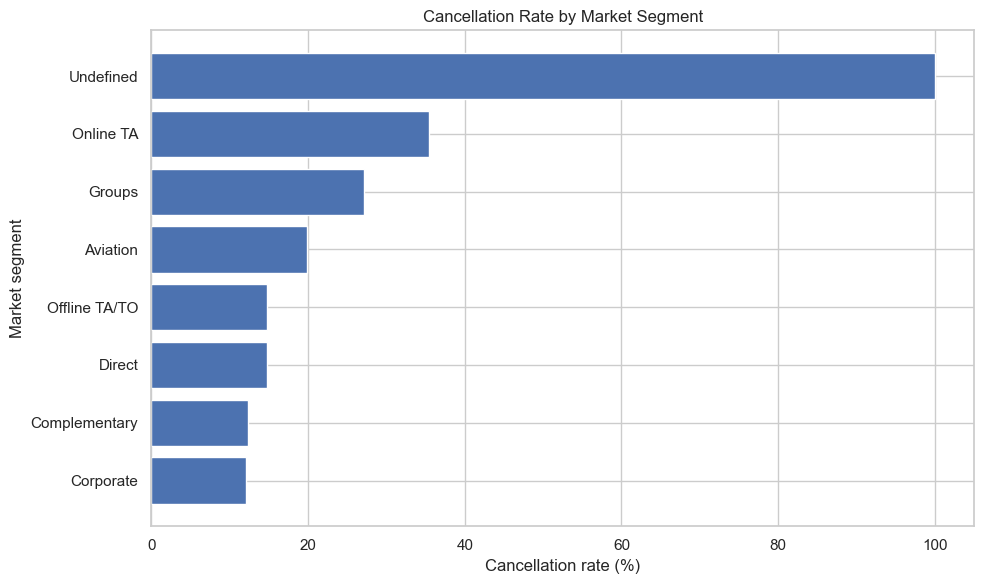

In [76]:
plot_data = segment_cancel.reset_index()
plt.figure(figsize=(10, 6))
plt.barh(plot_data["market_segment"].astype(str), plot_data["cancellation_rate_pct"])
plt.title("Cancellation Rate by Market Segment")
plt.xlabel("Cancellation rate (%)")
plt.ylabel("Market segment")
plt.tight_layout()
plt.show()

**Inner pattern:** cancellation behavior differs substantially by market segment. **Online TA** bookings are around **35%** canceled, while **Corporate** bookings are around **12%**.

The acquisition channel is therefore an important behavioral signal.


# 13. Deeper Pattern 5 — Lead Time × Special Requests

In [77]:
df_clean["lead_band"] = pd.cut(
    df_clean["lead_time"],
    bins=[-1, 30, 90, 180, 365, np.inf],
    labels=["0-30", "31-90", "91-180", "181-365", "366+"]
)

df_clean["request_band"] = pd.cut(
    df_clean["total_of_special_requests"],
    bins=[-1, 0, 1, 2, np.inf],
    labels=["0", "1", "2", "3+"]
)

interaction = (
    df_clean.groupby(["lead_band", "request_band"], observed=False)["is_canceled"]
    .agg(["mean", "count"])
    .reset_index()
)
interaction["cancellation_rate_pct"] = (interaction["mean"] * 100).round(1)

pivot_interaction = interaction.pivot(
    index="lead_band",
    columns="request_band",
    values="cancellation_rate_pct"
)
pivot_interaction


request_band,0,1,2,3+
lead_band,,,,
0-30,19.4,13.7,12.1,10.6
31-90,40.2,25.8,23.0,18.0
91-180,44.5,27.3,25.7,16.7
181-365,45.8,34.9,33.9,23.5
366+,57.0,9.2,11.8,12.5


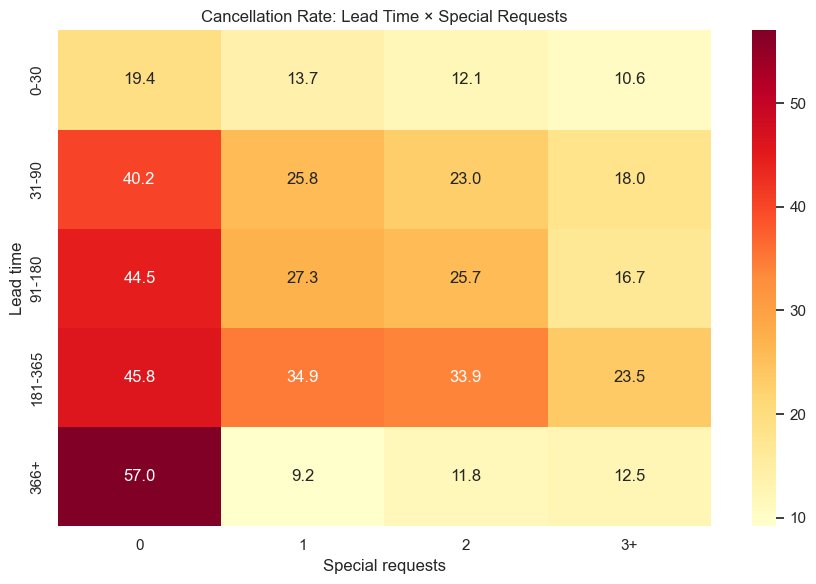

In [78]:
plt.figure(figsize=(9, 6))
sns.heatmap(pivot_interaction, annot=True, fmt=".1f", cmap="YlOrRd")
plt.title("Cancellation Rate: Lead Time × Special Requests")
plt.xlabel("Special requests")
plt.ylabel("Lead time")
plt.tight_layout()
plt.show()


### Why this is a deeper pattern

A simple correlation looks at variables one at a time. This interaction looks at **two variables together**.

Across most lead-time groups, bookings with **zero special requests** have higher cancellation rates than bookings with requests. At the same time, longer lead times generally increase cancellation risk.

Therefore, a booking with **long lead time + no special requests** represents a more concerning behavioral profile than a booking with the same lead time and several requests.

This is the kind of inner relationship that can be missed by basic descriptive analysis.


# 14. Deeper Pattern 6 — Family vs Non-Family Bookings

In [79]:
family_cancel = (
    df_clean.groupby("is_family")["is_canceled"]
    .agg(["mean", "count"])
)
family_cancel["cancellation_rate_pct"] = (family_cancel["mean"] * 100).round(1)
family_cancel.index = ["Non-family booking", "Family booking"]
family_cancel


,mean,count,cancellation_rate_pct
Non-family booking,0.267468,78099,26.7
Family booking,0.342524,9103,34.3


Family bookings show a higher cancellation rate than non-family bookings in this dataset (about **34% vs 27%**).

This does not mean families are less reliable. It may reflect differences in trip planning, group size, travel timing, or booking channel. The analytical finding is simply that **party composition is associated with cancellation behavior**.


# 15. Deeper Pattern 7 — Reserved Room vs Assigned Room

In [80]:
room_mismatch = (
    df_clean.groupby("room_mismatch")["is_canceled"]
    .agg(["mean", "count"])
)
room_mismatch["cancellation_rate_pct"] = (room_mismatch["mean"] * 100).round(1)
room_mismatch.index = ["Room matched", "Room changed"]
room_mismatch


,mean,count,cancellation_rate_pct
Room matched,0.315141,74224,31.5
Room changed,0.047465,12978,4.7


An especially strong association appears here: bookings where the assigned room differs from the reserved room have a much lower observed cancellation rate.

**Caution:** this does not mean changing a room prevents cancellation. Room assignment is an operational outcome and may itself depend on whether a booking remains active. Treat this as an interesting pattern, not a causal business rule.


# 16. Deeper Pattern 8 — Seasonality and Pricing

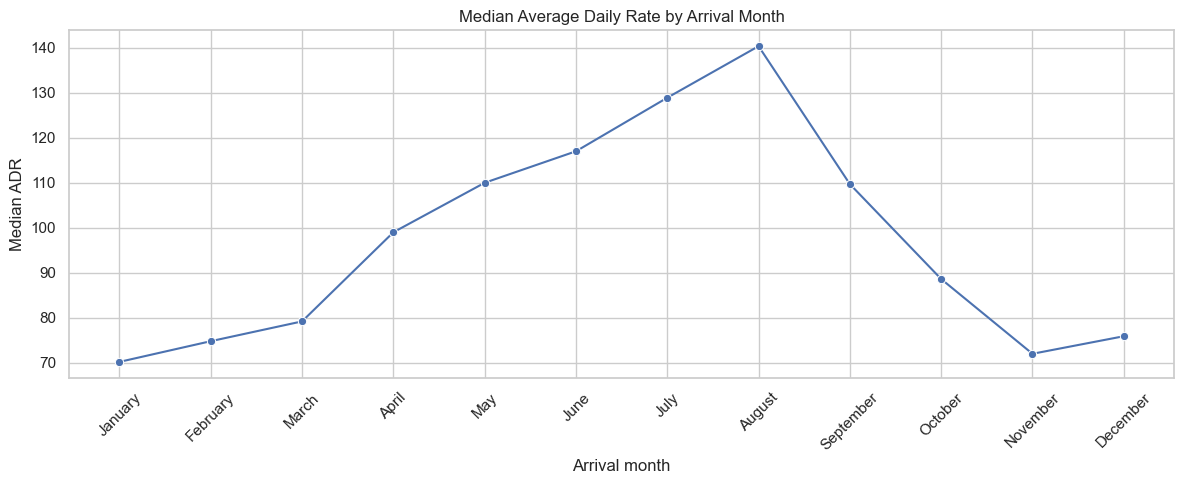

arrival_date_month
January       70.20
February      74.80
March         79.20
April         99.00
May          110.00
June         117.00
July         128.90
August       140.35
September    109.70
October       88.61
November      72.00
December      75.90
Name: adr, dtype: float64

In [81]:
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

monthly_adr = (
    df_clean.groupby("arrival_date_month")["adr"]
    .median()
    .reindex(month_order)
)

plt.figure(figsize=(12, 5))
sns.lineplot(x=monthly_adr.index, y=monthly_adr.values, marker="o")
plt.title("Median Average Daily Rate by Arrival Month")
plt.xlabel("Arrival month")
plt.ylabel("Median ADR")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

monthly_adr.round(2)


Median ADR rises toward the middle of the year and is highest around **July–August**, while several winter months are cheaper.

This shows a strong relationship between **arrival season and price**, which can support seasonal pricing and travel planning.


# 17. Deeper Pattern 9 — Booking Value at Risk

In [82]:
value_by_segment = (
    df_clean.groupby("market_segment")
    .agg(
        bookings=("is_canceled", "size"),
        cancellations=("is_canceled", "sum"),
        cancellation_rate=("is_canceled", "mean"),
        estimated_booking_value=("estimated_booking_value", "sum"),
        estimated_canceled_value=(
            "estimated_booking_value",
            lambda x: x[df_clean.loc[x.index, "is_canceled"] == 1].sum()
        )
    )
)

value_by_segment["cancellation_rate_pct"] = (
    value_by_segment["cancellation_rate"] * 100
).round(1)

value_by_segment.sort_values(
    "estimated_canceled_value", ascending=False
).round(2)


,bookings,cancellations,cancellation_rate,estimated_booking_value,estimated_canceled_value,cancellation_rate_pct
market_segment,,,,,,
Online TA,51548,18242,0.35,22258603.39,9292901.94,35.4
Direct,11774,1737,0.15,4853630.35,929714.23,14.8
Offline TA/TO,13851,2055,0.15,5410755.95,815368.82,14.8
Groups,4919,1332,0.27,1237745.72,315619.75,27.1
Corporate,4190,509,0.12,593684.08,110415.25,12.1
Aviation,226,45,0.20,83033.36,14065.00,19.9
Complementary,692,85,0.12,5074.52,269.99,12.3
Undefined,2,2,1.00,48.00,48.00,100.0


### Why this matters

Cancellation **rate** measures frequency, while estimated canceled booking value measures potential financial exposure.

The estimate is:

**ADR × total nights**

for canceled bookings. It is not confirmed lost revenue because a canceled room may later be resold.

This gives a more business-focused view: the segment with the highest cancellation rate is not automatically the segment with the highest estimated value at risk.


# 18. Categorical Relationships with Cramér's V

Pearson correlation is mainly useful for numerical variables. For categorical variables, **Cramér's V** provides a measure of association.

We use it to rank how strongly different categorical booking/customer variables are associated with cancellation status.

In [83]:
def cramers_v(x, y):
    table = pd.crosstab(x, y)
    chi2 = chi2_contingency(table)[0]
    n = table.sum().sum()
    r, k = table.shape

    phi2 = chi2 / n
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)

    return np.sqrt(phi2corr / min(kcorr - 1, rcorr - 1))

categorical_vars = [
    "hotel", "market_segment", "deposit_type", "customer_type",
    "meal", "reserved_room_type", "distribution_channel",
    "is_repeated_guest"
]

cramers_results = []

for col in categorical_vars:
    cramers_results.append({
        "variable": col,
        "cramers_v_with_cancellation": cramers_v(
            df_clean[col],
            df_clean["is_canceled"]
        )
    })

cramers_df = pd.DataFrame(cramers_results).sort_values(
    "cramers_v_with_cancellation", ascending=False
)

cramers_df


,variable,cramers_v_with_cancellation
1,market_segment,0.221039
2,deposit_type,0.164906
6,distribution_channel,0.152133
3,customer_type,0.127045
7,is_repeated_guest,0.088647
0,hotel,0.071949
4,meal,0.064045
5,reserved_room_type,0.055708


Cramér's V lets us move beyond a simple numerical correlation matrix and ask:

> **Which categorical characteristics are most strongly associated with cancellation?**

The score is useful for screening and ranking relationships, while the cancellation-rate tables explain the direction of the behavior.


# 19. Combined Customer Behavior Profile

In [84]:
customer_profile = df_clean.groupby(
    ["is_repeated_guest", "is_family"]
).agg(
    bookings=("is_canceled", "size"),
    cancellation_rate=("is_canceled", "mean"),
    median_lead_time=("lead_time", "median"),
    median_special_requests=("total_of_special_requests", "median"),
    median_total_nights=("total_nights", "median"),
    median_adr=("adr", "median")
).reset_index()

customer_profile["cancellation_rate_pct"] = (
    customer_profile["cancellation_rate"] * 100
).round(1)

customer_profile


,is_repeated_guest,is_family,bookings,cancellation_rate,median_lead_time,median_special_requests,median_total_nights,median_adr,cancellation_rate_pct
0,0,0,74832,0.275724,52.0,0.0,3.0,96.0,27.6
1,0,1,9007,0.345731,63.0,1.0,3.0,149.2,34.6
2,1,0,3267,0.078359,3.0,0.0,1.0,65.0,7.8
3,1,1,96,0.041667,3.0,1.0,1.0,87.0,4.2


This profile combines loyalty, family status, cancellation behavior, booking horizon, requests, stay length, and price.

It shows how customer behavior becomes more meaningful when several variables are considered together instead of analyzing each column in isolation.


# 20. Key Findings — Inner Patterns Discovered

### 1. Booking timing matters
Longer lead times are associated with higher cancellation rates.

### 2. Customer engagement is informative
More special requests are associated with lower cancellation rates.

### 3. Repeat guests are much more stable
Repeat guests have a substantially lower cancellation rate than non-repeated guests.

### 4. Booking channel changes the risk profile
Online TA bookings show much higher cancellation rates than corporate bookings.

### 5. Interactions reveal more than single variables
Lead time combined with special requests produces a more informative cancellation-risk profile than either variable alone.

### 6. Family status is associated with cancellation
Family bookings have a higher observed cancellation rate than non-family bookings.

### 7. Room changes show a strong association
Room mismatch is associated with lower observed cancellation, but this should not be interpreted causally because room assignment is part of the booking lifecycle.

### 8. Price is seasonal
Median ADR rises during the middle of the year, especially around July–August.

### 9. Cancellation frequency and financial exposure are different
A segment can have many cancellations without necessarily having the greatest estimated booking value at risk.

---

## Overall conclusion

The most important lesson is that **customer behavior is multidimensional**. Cancellation is connected to booking timing, loyalty, special requests, market segment, family status, and operational characteristics.

This analysis provides a strong foundation for a next step such as:

- building a **hotel cancellation prediction model**
- creating a **customer segmentation model**
- developing a **hotel revenue/cancellation dashboard**
- investigating **high-risk booking profiles**
- testing whether these relationships remain after controlling for other variables
